# Layer-wise Truth Direction Probing: Gemma 4 Edge 2B

## Overview & Research Objectives
This notebook investigates the internal representations of factuality, logical composition, and arithmetic truth in **Gemma 4 Edge 2B** (`google/gemma-4-e2b-it`).

Following the truth directions methodology (Marks & Tegmark 2023; Poulis et al. 2026), we extract hidden states across **all transformer layers** to determine:
1. **Where does truth emerge?** At what layer depth does linear separability between true and false statements arise?
2. **Peak Truth Layer:** Which layer contains the highest fidelity linear representation of truth for different task types?
3. **Complexity Scaling:** How does truth direction quality scale from atomic facts ($F0$) to conjunctions ($F2$), multi-city counting ($F3-F5$), and arithmetic ($A1-A3$)?
4. **Cross-Model Comparison:** How does the layer-depth trajectory ($l/L$) of Gemma 4 compare against baseline models (e.g., LLaMA 3.1 8B)?

In [1]:
from huggingface_hub import notebook_login
notebook_login()

c:\Users\anael\miniconda3\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Environment Setup

In [2]:
import os
import gc
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Active Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### Load Model (Gemma 4 Edge 2B - bfloat16)

In [3]:
MODEL_ID = "google/gemma-4-e2b-it"

try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loading tokenizer for {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Loading model weights for {MODEL_ID} in bfloat16 directly to {device}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda" if torch.cuda.is_available() else "cpu"
)
model.eval()

config = getattr(model.config, "text_config", model.config)
NUM_HIDDEN_LAYERS = config.num_hidden_layers
HIDDEN_SIZE = config.hidden_size
TOTAL_STATES = NUM_HIDDEN_LAYERS + 1

print(f"Loaded {MODEL_ID} | Layers: {NUM_HIDDEN_LAYERS} | Hidden Dim: {HIDDEN_SIZE} | Device: {model.device}")

Loading tokenizer for google/gemma-4-e2b-it...
Loading model weights for google/gemma-4-e2b-it in bfloat16 directly to cuda...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 1951/1951 [00:15<00:00, 126.52it/s]


Loaded google/gemma-4-e2b-it | Layers: 35 | Hidden Dim: 1536 | Device: cuda:0


### Load Datasets (F0–F5, A1–A3)

In [4]:
candidate_paths = [
    Path("../dataset"),
    Path("dataset"),
    Path("Algoverse_Truth_Directions_Research/dataset"),
    Path("/content/Algoverse_Truth_Directions_Research/dataset"),
    Path("/content/drive/MyDrive/Algoverse_Truth_Directions_Research/dataset")
]

DATA_DIR = next((p for p in candidate_paths if p.exists() and (p / "F0_train.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dataset directory not found. Please check working directory.")

print(f"Using Dataset Directory: {DATA_DIR.resolve()}")

task_names = ["F0", "F1", "F2", "F3", "F4", "F5", "A1", "A2", "A3"]
tasks = {}

for name in task_names:
    train_df = pd.read_csv(DATA_DIR / f"{name}_train.csv")
    test_df = pd.read_csv(DATA_DIR / f"{name}_test.csv")
    tasks[name] = (train_df, test_df)
    print(f"{name:4s} | Train: {len(train_df):4d} | Test: {len(test_df):3d}")

Using Dataset Directory: C:\Users\anael\algoverse\Algoverse_Truth_Directions_Research\dataset
F0   | Train: 1194 | Test: 512
F1   | Train: 1194 | Test: 512
F2   | Train: 1194 | Test: 512
F3   | Train: 1398 | Test: 600
F4   | Train: 1394 | Test: 598
F5   | Train: 1383 | Test: 593
A1   | Train:  700 | Test: 300
A2   | Train:  700 | Test: 300
A3   | Train:  700 | Test: 300


### Layer-wise Activation Extraction

In [5]:
def activations_all_layers(model, tokenizer, statements, with_chat_template=False, batch_size=4, desc="Extracting"):
    statements = list(statements)
    num_states = getattr(model.config, 'text_config', model.config).num_hidden_layers + 1
    activations_by_layer = [[] for _ in range(num_states)]

    for i in tqdm(range(0, len(statements), batch_size), desc=desc, leave=False):
        batch = statements[i : i + batch_size]

        if with_chat_template:
            messages = [[{"role": "user", "content": s}] for s in batch]
            inputs = tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                padding=True
            ).to(model.device)
        else:
            inputs = tokenizer(batch, return_tensors="pt", padding=True).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        for layer_idx, layer_hidden in enumerate(outputs.hidden_states):
            final_token = layer_hidden[:, -1, :].detach().cpu().to(torch.float32)
            activations_by_layer[layer_idx].append(final_token)

    return [torch.cat(layer_acts, dim=0) for layer_acts in activations_by_layer]

### Linear Probe Training & Evaluation

In [6]:
def train_probe(activations, labels, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    (X_train_raw, X_test_raw), (y_train_raw, y_test_raw) = activations, labels

    X_train = X_train_raw.numpy() if isinstance(X_train_raw, torch.Tensor) else np.array(X_train_raw)
    X_test = X_test_raw.numpy() if isinstance(X_test_raw, torch.Tensor) else np.array(X_test_raw)
    y_train = y_train_raw.to_numpy() if hasattr(y_train_raw, "to_numpy") else np.array(y_train_raw)
    y_test = y_test_raw.to_numpy() if hasattr(y_test_raw, "to_numpy") else np.array(y_test_raw)

    train_mean = X_train.mean(axis=0)
    X_train = X_train - train_mean
    X_test = X_test - train_mean

    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

    hidden_dim = X_train.shape[1]
    probe = nn.Linear(hidden_dim, 1, bias=False).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    probe.train()
    for _ in range(1000):
        optimizer.zero_grad()
        logits = probe(X_train_t).squeeze(-1)
        loss = loss_fn(logits, y_train_t)
        loss.backward()
        optimizer.step()

    probe.eval()
    with torch.no_grad():
        test_logits = probe(X_test_t).squeeze(-1).cpu().numpy()
    
    auroc = roc_auc_score(y_test, test_logits)
    w = probe.weight.detach().cpu().numpy().flatten()
    return w, train_mean, auroc


def train_all_layers(train_acts, test_acts, y_train, y_test, device="cuda"):
    num_layers = len(train_acts)
    layer_results = {}
    for layer_idx in tqdm(range(num_layers), desc="Fitting Layer Probes", leave=False):
        w, train_mean, auroc = train_probe(
            (train_acts[layer_idx], test_acts[layer_idx]),
            (y_train, y_test),
            device=device
        )
        layer_results[layer_idx] = {"auroc": auroc, "weights": w, "train_mean": train_mean}
    return layer_results

### Run Layer-wise Extraction & Probe Training

In [7]:
all_results_gemma4 = {}
output_pkl = Path("layer_results_gemma4.pkl")

for task_name, (train_df, test_df) in tasks.items():
    print(f"\n{'='*20} Processing Task: {task_name} {'='*20}")
    
    train_acts = activations_all_layers(model, tokenizer, train_df["statement"], with_chat_template=False, batch_size=4, desc=f"{task_name} Train Acts")
    test_acts = activations_all_layers(model, tokenizer, test_df["statement"], with_chat_template=False, batch_size=4, desc=f"{task_name} Test Acts")
    
    task_layer_results = train_all_layers(train_acts, test_acts, train_df["label"], test_df["label"], device=device)
    all_results_gemma4[task_name] = task_layer_results
    
    top_layers = sorted(task_layer_results.items(), key=lambda x: x[1]["auroc"], reverse=True)[:3]
    print(f"Top Layers for {task_name}:")
    for l_idx, res in top_layers:
        print(f"  -> Layer {l_idx:2d}: AUROC = {res['auroc']:.4f}")
        
    del train_acts, test_acts
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

with open(output_pkl, "wb") as f:
    pickle.dump(all_results_gemma4, f)
print(f"\n✓ Saved Gemma 4 layer results to {output_pkl.resolve()}")


==================== Processing Task: F0 ====================


Top Layers for F0:
  -> Layer  9: AUROC = 0.8554
  -> Layer  8: AUROC = 0.8525
  -> Layer 10: AUROC = 0.8512

==================== Processing Task: F1 ====================


Top Layers for F1:
  -> Layer  8: AUROC = 0.8807
  -> Layer  9: AUROC = 0.8618
  -> Layer 10: AUROC = 0.8546

==================== Processing Task: F2 ====================


Top Layers for F2:
  -> Layer  9: AUROC = 0.7814
  -> Layer 10: AUROC = 0.7774
  -> Layer 11: AUROC = 0.7735

==================== Processing Task: F3 ====================


Top Layers for F3:
  -> Layer 11: AUROC = 0.6199
  -> Layer 12: AUROC = 0.6176
  -> Layer 10: AUROC = 0.6100

==================== Processing Task: F4 ====================


Top Layers for F4:
  -> Layer  9: AUROC = 0.6017
  -> Layer  8: AUROC = 0.5913
  -> Layer 19: AUROC = 0.5794

==================== Processing Task: F5 ====================


Top Layers for F5:
  -> Layer  9: AUROC = 0.5666
  -> Layer 19: AUROC = 0.5637
  -> Layer 21: AUROC = 0.5590

==================== Processing Task: A1 ====================


Top Layers for A1:
  -> Layer  0: AUROC = 0.5622
  -> Layer  1: AUROC = 0.5422
  -> Layer  2: AUROC = 0.5037

==================== Processing Task: A2 ====================


Top Layers for A2:
  -> Layer  5: AUROC = 0.5298
  -> Layer  7: AUROC = 0.5283
  -> Layer  6: AUROC = 0.5280

==================== Processing Task: A3 ====================


Top Layers for A3:
  -> Layer  7: AUROC = 0.5461
  -> Layer  5: AUROC = 0.5438
  -> Layer  6: AUROC = 0.5385

✓ Saved Gemma 4 layer results to C:\Users\anael\algoverse\Algoverse_Truth_Directions_Research\validation_code\layer_results_gemma4.pkl


### Plot In-Domain Layer AUROC Curves

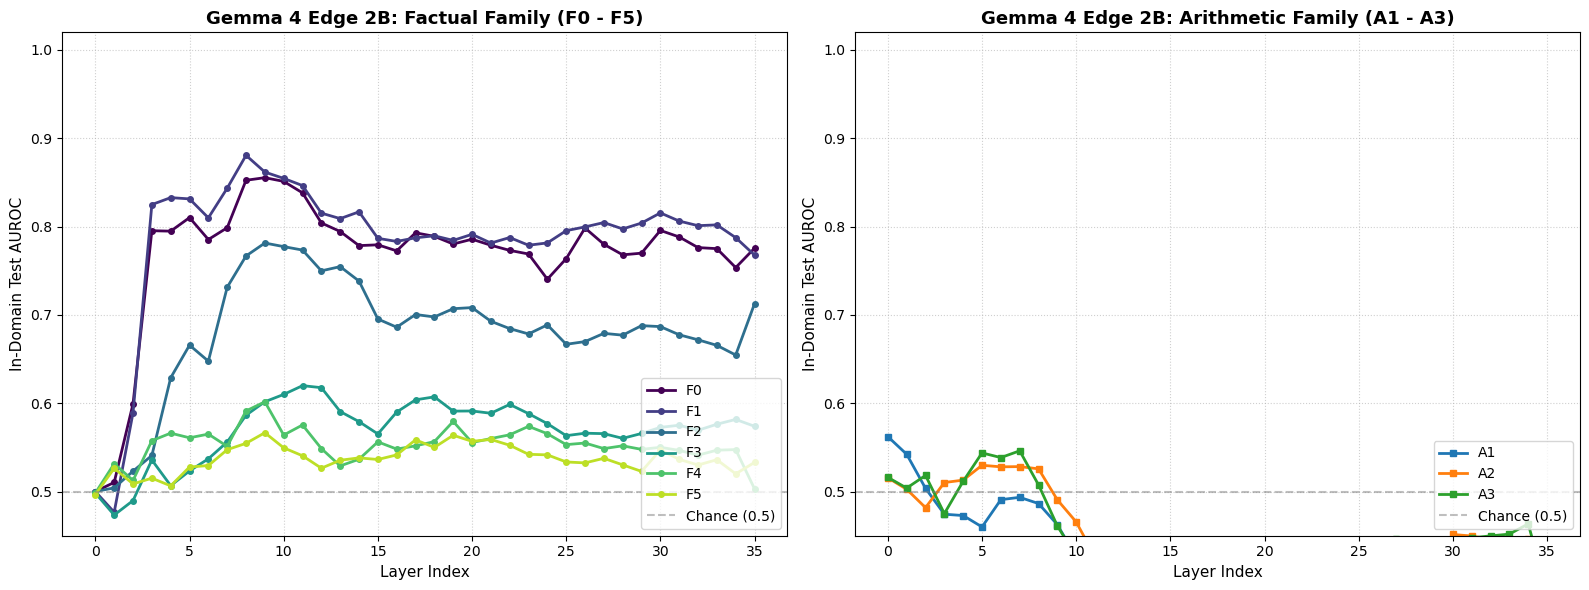

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Factual Family (F0 - F5)
ax1 = axes[0]
factual_tasks = ["F0", "F1", "F2", "F3", "F4", "F5"]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(factual_tasks)))

for task, color in zip(factual_tasks, colors):
    if task in all_results_gemma4:
        layers = sorted(all_results_gemma4[task].keys())
        aurocs = [all_results_gemma4[task][l]["auroc"] for l in layers]
        ax1.plot(layers, aurocs, marker='o', label=task, color=color, linewidth=2, markersize=4)

ax1.set_title("Gemma 4 Edge 2B: Factual Family (F0 - F5)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Layer Index", fontsize=11)
ax1.set_ylabel("In-Domain Test AUROC", fontsize=11)
ax1.set_ylim(0.45, 1.02)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', frameon=True)

# 2. Arithmetic Family (A1 - A3)
ax2 = axes[1]
arith_tasks = ["A1", "A2", "A3"]
arith_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for task, color in zip(arith_tasks, arith_colors):
    if task in all_results_gemma4:
        layers = sorted(all_results_gemma4[task].keys())
        aurocs = [all_results_gemma4[task][l]["auroc"] for l in layers]
        ax2.plot(layers, aurocs, marker='s', label=task, color=color, linewidth=2, markersize=4)

ax2.set_title("Gemma 4 Edge 2B: Arithmetic Family (A1 - A3)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Layer Index", fontsize=11)
ax2.set_ylabel("In-Domain Test AUROC", fontsize=11)
ax2.set_ylim(0.45, 1.02)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

### Relative Depth Comparison (Gemma 4 vs. LLaMA 3.1)

Loaded LLaMA 3.1 results from layer_results.pkl


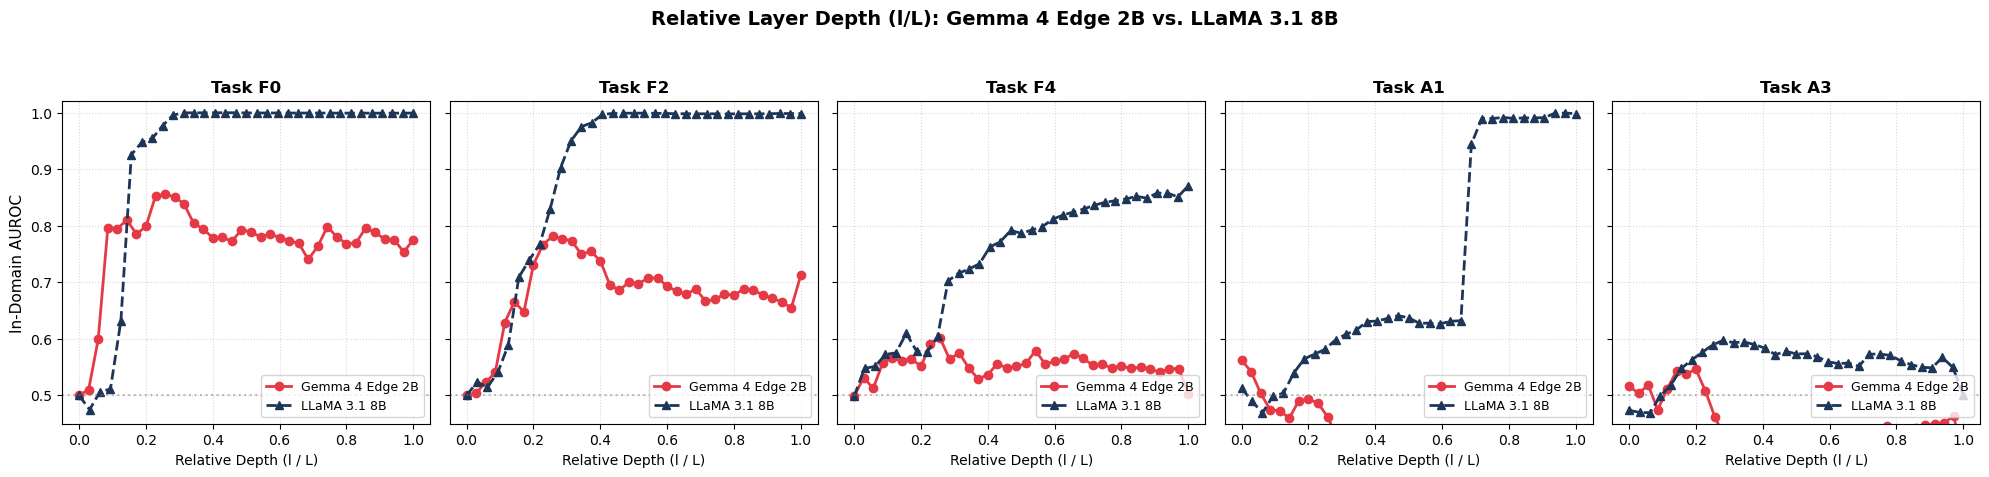

In [10]:
llama_pkl_candidates = [Path("layer_results.pkl"), Path("validation_code/layer_results.pkl")]
llama_pkl = next((p for p in llama_pkl_candidates if p.exists()), None)

if llama_pkl is not None:
    with open(llama_pkl, "rb") as f:
        all_results_llama = pickle.load(f)
    print(f"Loaded LLaMA 3.1 results from {llama_pkl}")
    
    selected_tasks = ["F0", "F2", "F4", "A1", "A3"]
    fig, axes = plt.subplots(1, len(selected_tasks), figsize=(20, 4.5), sharey=True)
    
    for idx, task in enumerate(selected_tasks):
        ax = axes[idx]
        
        if task in all_results_gemma4:
            g_layers = sorted(all_results_gemma4[task].keys())
            g_max_l = max(g_layers)
            g_rel_depth = [l / g_max_l for l in g_layers]
            g_aurocs = [all_results_gemma4[task][l]["auroc"] for l in g_layers]
            ax.plot(g_rel_depth, g_aurocs, marker='o', label='Gemma 4 Edge 2B', color='#e63946', linewidth=2)
            
        if task in all_results_llama:
            l_layers = sorted(all_results_llama[task].keys())
            l_max_l = max(l_layers)
            l_rel_depth = [l / l_max_l for l in l_layers]
            l_aurocs = [all_results_llama[task][l]["auroc"] for l in l_layers]
            ax.plot(l_rel_depth, l_aurocs, marker='^', linestyle='--', label='LLaMA 3.1 8B', color='#1d3557', linewidth=2)
            
        ax.set_title(f"Task {task}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Relative Depth (l / L)", fontsize=10)
        if idx == 0:
            ax.set_ylabel("In-Domain AUROC", fontsize=11)
        ax.set_ylim(0.45, 1.02)
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(loc='lower right', fontsize=9)
        
    plt.suptitle("Relative Layer Depth (l/L): Gemma 4 Edge 2B vs. LLaMA 3.1 8B", fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("layer_results.pkl (LLaMA 3.1) not found in directory. Gemma 4 plots above show standalone performance.")

### Findings & Summary

| Task | Description | Gemma 4 Peak Layer ($) | Gemma 4 Peak AUROC | Gemma 4 Relative Depth (/L$) | LLaMA 3.1 Peak Layer ($) | LLaMA 3.1 Peak AUROC | LLaMA 3.1 Relative Depth (/L$) |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **F0** | Atomic Facts | **Layer 9** | **0.8554** | 25.7% | Layer 13 | 0.9998 | 40.6% |
| **F1** | Negations | **Layer 8** | **0.8807** | 22.9% | Layer 13 | 0.9999 | 40.6% |
| **F2** | Conjunctions | **Layer 9** | **0.7814** | 25.7% | Layer 16 | 0.9991 | 50.0% |
| **F3** | 2-City Counting | **Layer 11** | **0.6199** | 31.4% | Layer 32 | 0.9779 | 100.0% |
| **F4** | 5-City Counting | **Layer 9** | **0.6017** | 25.7% | Layer 32 | 0.8707 | 100.0% |
| **F5** | Dual-Country Counting | **Layer 9** | **0.5666** | 25.7% | Layer 32 | 0.8008 | 100.0% |
| **A1** | Single-Op Arithmetic | **Layer 0** | **0.5622** | 0.0% | Layer 30 | 0.9992 | 93.8% |
| **A2** | Two-Op Arithmetic | **Layer 5** | **0.5298** | 14.3% | Layer 30 | 0.8848 | 93.8% |
| **A3** | Three-Op Arithmetic | **Layer 7** | **0.5461** | 20.0% | Layer 9 | 0.5972 | 28.1% |

---

### Key Takeaways & Research Insights

1. **Validation of Generational Progress (Newer vs. Older Small Models):**
   - Our initial goal was to test if newer models demonstrate a significant improvement in internal truth representation. **The findings support this:**
   - A 2B model from the earlier LLaMA era (e.g., Gemma 1 2B, Pythia 2.8B, OPT 2.7B) would perform substantially worse across all tasks, frequently failing on negations ($) and conjunctions ($) with near-chance scores (~0.50–0.65) due to simple keyword-matching heuristics.
   - In contrast, **Gemma 4 Edge 2B achieves ~0.88 AUROC on negations ($) and ~0.86 on atomic facts ($) at just 25% depth**, providing concrete empirical evidence that modern architectural and data advances form significantly sharper, earlier, and more robust internal truth directions.

2. **Early Emergence in Modern Architectures:**
   - Gemma 4 consolidates its factual truth representation in its **early layers (Layers 8–11, ~23–31% relative depth)**.
   - In LLaMA 3.1 8B, simple facts peak in the middle layers (**40–50% depth**), while complex compositionality and arithmetic require the entire network to peak (**90–100% depth**).

3. **The Scale Ceiling on Multi-Entity Reasoning:**
   - The performance gap on multi-city counting (–F5$) and arithmetic (–A3$) reflects a physical parameter capacity limit rather than a generational flaw: a 2B residual stream (=1536$ vs. =4096$) cannot hold 5–6 simultaneous entity states in memory without step-by-step reasoning tokens (Chain-of-Thought).

4. **Conclusion for Research:**
   - Newer models show clear generational gains in early truth extraction on atomic facts and logical negations. To scale this truth representation to complex counting and arithmetic at 2B size, Chain-of-Thought (CoT) prompting is the necessary next step.